# Inégalités territoriales d'accès aux équipements sportifs en France

> **Problématique** : Les inégalités territoriales d'accès aux équipements sportifs en France sont-elles le reflet des inégalités socio-économiques ?

**Auteurs** : DELETANG Arthur, GOUALOU Maxence, SERVANT Lucas  
**Cours** : Python pour la Data Science — 2025-2026

---
## Sommaire
1. [Imports](#1---imports)
2. [Collecte des données](#2---collecte-des-données)
3. [Nettoyage et fusion](#3---nettoyage-et-fusion)
4. [Analyse descriptive](#4---analyse-descriptive)
5. [Visualisation cartographique](#5---visualisation-cartographique)
6. [Modélisation](#6---modélisation)
7. [Conclusion](#7---conclusion)

---
## 1 - Imports

In [1]:
!pip install pandas numpy matplotlib seaborn geopandas folium requests beautifulsoup4 scikit-learn lxml

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import requests
from bs4 import BeautifulSoup
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 87.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [folium]2m2/4 [branca]


---
## 2 - Collecte des données

### 2.1 Équipements sportifs — API REST Ministère des Sports

On interroge l'API Opendatasoft du portail Data ES qui expose le recensement national des équipements sportifs (RES). L'export CSV direct évite tout téléchargement manuel.

Source : https://equipements.sports.gouv.fr

In [2]:
url_res = (
    "https://equipements.sports.gouv.fr/api/explore/v2.1/"
    "catalog/datasets/data-es/exports/csv"
    "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
)

print("Téléchargement du RES...")
df_res = pd.read_csv(url_res, sep=";", encoding="utf-8", low_memory=False)
print(f"{len(df_res):,} équipements")
df_res.head(3)

Téléchargement du RES...
333,792 équipements


,Numéro de l'équipement sportif,Mise à jour de la fiche équipement,Numéro de l'installation sportive,Date de l'enquête,Nom de l'installation sportive,SIRET Installation,Adresse,Code Postal,Commune nom,Commune INSEE,...,Accessibilité aux personnes en situation de handicap sensoriel aux tribunes,Accessibilité aux personnes en situation de handicap sensoriel aux vestiaires,Longitude,Latitude,Type de particularité de l'installation (brute),Activités,QPV,QPV à 200 mètres,Catégorie,gen_2024Fin_Labellisation
0,E003I783810001,2025-03-31,I783810001,2025-03-31,SALLE POLYVALENTE,2.178038e+13,7 ROUTE DE GAMBAIS,78550,Maulette,78381,...,False,False,1.62527,48.79221,NaN,Basket-Ball,NaN,NaN,NaN,NaN
1,E002I781170008,2025-03-31,I781170008,2025-03-31,GOLF DE BUC,NaN,1 rue de la Croix Blanche,78530,Buc,78117,...,False,False,2.13010,48.76409,NaN,Golf,NaN,NaN,NaN,NaN
2,E003I783830005,2025-03-31,I783830005,2025-03-31,GYMNASE DU BOIS,2.178038e+13,AVENUE DE NORMANDIE,78310,Maurepas,78383,...,False,False,1.93958,48.76671,NaN,Gymnastique Artistique,NaN,QN07816M,structurant,NaN


### 2.2 Données socio-économiques — INSEE via Data ES

Ce dataset expose les principales variables INSEE au niveau communal : population, superficie, revenu médian (MED20), taux de pauvreté (TP6020), typologie rurale/urbaine. On l'agrège ensuite par département.

Source : https://equipements.sports.gouv.fr/explore/dataset/insee-2020-geoapi-2023

In [3]:
url_insee = (
    "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/"
    "insee-2020-geoapi-2023/exports/csv"
    "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
)

print("Téléchargement données INSEE communes...")
df_communes = pd.read_csv(url_insee, sep=";", encoding="utf-8", low_memory=False)
print(f"{len(df_communes):,} communes — {df_communes.shape[1]} colonnes")
df_communes.head(3)

Téléchargement données INSEE communes...


35,075 communes — 47 colonnes


,codeCommune,nomCommune,codeEpci,nomEpci,codeDepartement,nomDepartement,codeRegion,nomRegion,population,surface,...,lib_ville,code_bdv,lib_bdv,zfrr,zrr,TYPO_RURB_CRTE,vas,dens_niveau,dens_lib,commune_loi_montagne
0,84118,Saint-Saturnin-lès-Apt,200040624,CC Pays d'Apt-Luberon,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,2910,7682.46,...,Saint-Saturnin-lès-Apt,84003,Apt,zfrr,NaN,RURAL,NaN,6.0,Rural à habitat dispersé,Loi Montagne
1,84119,Saint-Saturnin-lès-Avignon,248400251,CA du Grand Avignon (COGA),84,Vaucluse,93,Provence-Alpes-Côte d'Azur,5027,621.81,...,Saint-Saturnin-lès-Avignon,84007,Avignon,NaN,NaN,URBAIN,NaN,4.0,Ceintures urbaines,NaN
2,84120,Saint-Trinit,200035723,CC Ventoux Sud,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,120,1690.17,...,Saint-Trinit,84123,Sault,zfrr,NaN,RURAL,NaN,7.0,Rural à habitat très dispersé,Loi Montagne


---
## 3 - Nettoyage et fusion

Cette section explore d'abord la structure brute des deux sources principales, identifie les problèmes (valeurs manquantes, codes aberrants, doublons), les corrige, puis construit le DataFrame analytique final au niveau département.

### 3.1 Exploration et nettoyage du RES

In [4]:
# Structure générale du RES
print(f"Dimensions : {df_res.shape}")
print(f"\nColonnes disponibles :")
print(df_res.columns.tolist())

Dimensions : (333792, 114)

Colonnes disponibles :
["Numéro de l'équipement sportif", 'Mise à jour de la fiche équipement', "Numéro de l'installation sportive", "Date de l'enquête", "Nom de l'installation sportive", 'SIRET Installation', 'Adresse', 'Code Postal', 'Commune nom', 'Commune INSEE', "Type de particularité de l'installation", 'Unité Administrative Immatriculée (UAI)', "Accessibilité de l'installation en fonction du type handicap", "Accessibilité de l'installation en transport en commun des différents mode", 'Observation Installation', "Date de changement d'état de la fiche d'enquête", "Date de création de la fiche d'enquête", 'Installation hors-service', 'EPCI INSEE', 'EPCI Nom', 'Département Code', 'Département Nom', 'Région Code', 'Région Nom', 'Bassin de vie Code', 'Bassin de vie Nom', 'Arrondissement Code', 'Arrondissement Nom', 'Densite Niveau', 'Densite Catégorie', 'Département Code Complet', 'Réctorat Nom', 'ZRR Simplifié', "Nom de l'équipement sportif", "Type d'équip

In [ ]:
# Valeurs manquantes dans les colonnes clés du RES
cols_cles_res = [
    "Département Code", "Commune nom",
    "Type d'équipement sportif", "Famille d'équipement sportif"
]
na_res = df_res[cols_cles_res].isnull().sum().rename("NaN")
print("Valeurs manquantes dans les colonnes clés du RES :")
print(na_res)

Valeurs manquantes dans les colonnes clés du RES :
                              NaN    %
Département Code              199  0.1
Commune nom                     0  0.0
Type d'équipement sportif       1  0.0
Famille d'équipement sportif    1  0.0


In [6]:
# Vérification des codes département dans le RES
codes_dep_res = df_res["Département Code"].astype(str).str.strip().unique()
codes_dep_res_sorted = sorted(codes_dep_res)
print(f"{len(codes_dep_res_sorted)} codes départements uniques dans le RES :")
print(codes_dep_res_sorted)

108 codes départements uniques dans le RES :
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '975', '976', '977', '978', '986', '987', '988', 'nan']


In [7]:
# Vérification des doublons sur le numéro d'équipement
n_doublons = df_res.duplicated(subset=["Numéro de l'équipement sportif"]).sum()
print(f"Doublons sur le numéro d'équipement : {n_doublons}")

Doublons sur le numéro d'équipement : 84


In [ ]:
# Vérification et affichage des doublons sur le numéro d'équipement
n_doublons = df_res.duplicated(subset=["Numéro de l'équipement sportif"]).sum()
print(f"Doublons sur le numéro d'équipement : {n_doublons}")

# Afficher les lignes dupliquées
doublons = df_res[df_res.duplicated(subset=["Numéro de l'équipement sportif"], keep=False)]
doublons = doublons.sort_values("Numéro de l'équipement sportif")
doublons[["Numéro de l'équipement sportif", "Date de l'enquête", 
          "Nom de l'installation sportive", "Commune nom", "Département Code"]]

Les codes département du RES ne sont pas standardisés (certains s'écrivent '1' au lieu de '01'). On applique un zfill après filtrage pour corriger ce problème avant toute fusion."

In [8]:
# Nettoyage du RES :
# - standardiser le code département sur 2 caractères (zfill AVANT le filtre)
# - supprimer les lignes sans code département valide
# - supprimer les 84 doublons sur le numéro d'équipement

df_res["code_dep"] = (
    df_res["Département Code"]
    .astype(str)
    .str.strip()
    .str.replace("nan", "")       # transformer "nan" en chaîne vide
    .apply(lambda x: x.zfill(2) if x.isdigit() else x)  # zfill seulement si numérique
)

# Codes valides : 01 à 95, 2A, 2B, et les 4 DOM (971-974, 976)
mask_dep_valide = df_res["code_dep"].str.match(r"^0[1-9]$|^[1-9]\d$|^2[AB]$|^97[1-46]$")
n_exclus = (~mask_dep_valide).sum()
df_res = df_res[mask_dep_valide].copy()

# Suppression des doublons — garder la ligne la plus récente
df_res = df_res.sort_values("Date de l'enquête", ascending=False)
df_res = df_res.drop_duplicates(subset=["Numéro de l'équipement sportif"], keep="first")

print(f"{n_exclus} lignes exclues (code département invalide ou manquant)")
print(f"{84} doublons supprimés")
print(f"RES nettoyé : {len(df_res):,} équipements")
print(f"Codes département présents : {sorted(df_res['code_dep'].unique())}")

2577 lignes exclues (code département invalide ou manquant)
84 doublons supprimés
RES nettoyé : 331,134 équipements
Codes département présents : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '976']


### 3.2 Exploration et nettoyage de l'INSEE communes

In [9]:
# Structure générale INSEE
print(f"Dimensions : {df_communes.shape}")
print(f"\nColonnes disponibles :")
print(df_communes.columns.tolist())

Dimensions : (35075, 47)

Colonnes disponibles :
['codeCommune', 'nomCommune', 'codeEpci', 'nomEpci', 'codeDepartement', 'nomDepartement', 'codeRegion', 'nomRegion', 'population', 'surface', 'CODGEO', 'P20_POP', 'SUPERF', 'P20_MEN', 'P20_LOG', 'P20_RP', 'P20_RSECOCC', 'P20_LOGVAC', 'P20_RP_PROP', 'NBMENFISC20', 'PIMP20', 'MED20', 'TP6020', 'P20_EMPLT', 'P20_EMPLT_SAL', 'P20_POP1564', 'P20_CHOMEUR1564', 'P20_ACT1564', 'ETTOT20', 'ETAZ20', 'ETBE20', 'ETFZ20', 'ETGU20', 'ETGZ20', 'ETOQ20', 'ETTEF120', 'ETTEFP1020', 'lib_ville', 'code_bdv', 'lib_bdv', 'zfrr', 'zrr', 'TYPO_RURB_CRTE', 'vas', 'dens_niveau', 'dens_lib', 'commune_loi_montagne']


In [ ]:
# Valeurs manquantes dans les colonnes clés INSEE
cols_cles_insee = [
    "codeDepartement", "nomDepartement", "population", "surface",
    "MED20", "TP6020", "TYPO_RURB_CRTE"
]
na_insee = df_communes[cols_cles_insee].isnull().sum().rename("NaN")
print("Valeurs manquantes dans les colonnes clés INSEE :")
print(na_insee)

Valeurs manquantes dans les colonnes clés INSEE :
                 NaN    %
codeDepartement    0  0.0
nomDepartement     0  0.0
population         0  0.0
surface            0  0.0
MED20              0  0.0
TP6020             0  0.0
TYPO_RURB_CRTE   134  0.4

Note : MED20 et TP6020 sont soumises au secret statistique pour les petites communes.


In [11]:
# Vérification des codes département INSEE
codes_dep_insee = df_communes["codeDepartement"].astype(str).str.strip().unique()
print(f"{len(codes_dep_insee)} codes départements uniques dans INSEE :")
print(sorted(codes_dep_insee))

107 codes départements uniques dans INSEE :
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '975', '976', '977', '978', '986', '987', '988']


In [12]:
# Nettoyage INSEE :
# - standardiser le code département
# - convertir les colonnes numériques
# - exclure les collectivités hors champ (COM, autres territoires)
# - les 134 NaN de TYPO_RURB_CRTE sont conservés (traités comme "Non classifié")

df_communes["code_dep"] = df_communes["codeDepartement"].astype(str).str.strip().str.zfill(2)

for col in ["MED20", "TP6020", "population", "surface"]:
    df_communes[col] = pd.to_numeric(df_communes[col], errors="coerce")

# Garder métropole + 5 DOM (971-974, 976) — exclure COM et autres territoires
mask_dep_valide_insee = df_communes["code_dep"].str.match(r"^0[1-9]$|^[1-9]\d$|^2[AB]$|^97[1-46]$")
n_exclus_insee = (~mask_dep_valide_insee).sum()
df_communes = df_communes[mask_dep_valide_insee].copy()

# Traiter les NaN de TYPO_RURB_CRTE
df_communes["TYPO_RURB_CRTE"] = df_communes["TYPO_RURB_CRTE"].fillna("Non classifié")

print(f"{n_exclus_insee} communes exclues (collectivités hors champ)")

88 communes exclues (collectivités hors champ)


### 3.3 Agrégation INSEE : commune → département

In [13]:
# Population et superficie totales par département (somme directe)
df_pop_dep = (
    df_communes.groupby("code_dep")
    .agg(
        nom_dep       = ("nomDepartement", "first"),
        population    = ("population", "sum"),
        superficie_km2 = ("surface", lambda x: x.sum() / 100)  # ha → km²
    )
    .reset_index()
)
print(f"{len(df_pop_dep)} départements — population et superficie agrégées")
df_pop_dep.head(3)

101 départements — population et superficie agrégées


,code_dep,nom_dep,population,superficie_km2
0,01,Ain,657417,5783.4420
1,02,Aisne,528994,7403.4261
2,03,Allier,335628,7377.2245


On utilise une moyenne pondérée par la population plutôt qu'une moyenne simple, car agréger des médianes communales par une moyenne arithmétique donnerait autant de poids à une commune de 100 habitants qu'à une de 500 000.

In [14]:
# Revenu médian et taux de pauvreté : moyenne pondérée par la population
# (nécessaire car la médiane d'un département n'est pas la moyenne des médianes communales)
def moyenne_ponderee(groupe, col_valeur):
    mask = groupe[col_valeur].notna() & (groupe["population"] > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(groupe.loc[mask, col_valeur], weights=groupe.loc[mask, "population"])

df_revenus_dep = (
    df_communes.groupby("code_dep")
    .apply(lambda g: pd.Series({
        "revenu_median" : moyenne_ponderee(g, "MED20"),
        "taux_pauvrete" : moyenne_ponderee(g, "TP6020"),
    }), include_groups=False)
    .reset_index()
)
print(f"{len(df_revenus_dep)} départements — revenus et pauvreté agrégés")
df_revenus_dep.head(3)

101 départements — revenus et pauvreté agrégés


,code_dep,revenu_median,taux_pauvrete
0,01,25257.848413,7.439797
1,02,19823.451306,11.030959
2,03,20881.861078,9.408732


In [15]:
# Part des communes rurales par département
df_rural_dep = (
    df_communes.groupby("code_dep")
    .apply(lambda g: pd.Series({
        "part_rural": (g["TYPO_RURB_CRTE"].str.upper().str.contains("RURAL", na=False).sum()
                       / len(g) * 100)
    }), include_groups=False)
    .reset_index()
)
print(f"{len(df_rural_dep)} départements — ruralité agrégée")

101 départements — ruralité agrégée


### 3.4 Comptage des équipements par département

In [16]:
# Nombre d'équipements par département
nb_equip = (
    df_res.groupby("code_dep")
    .size()
    .reset_index(name="nb_equipements")
)
print(f"{len(nb_equip)} départements avec équipements")
nb_equip.head(3)

101 départements avec équipements


,code_dep,nb_equipements
0,01,4107
1,02,3636
2,03,2447


### 3.5 Fusion finale et construction des variables analytiques

In [17]:
# Fusion de toutes les sources
df = nb_equip.merge(df_pop_dep,     on="code_dep", how="inner")
df = df.merge(df_revenus_dep,       on="code_dep", how="left")
df = df.merge(df_rural_dep,         on="code_dep", how="left")

# Variables analytiques
df["equip_10k"] = (df["nb_equipements"] / df["population"]) * 10_000
df["densite"]   = df["population"] / df["superficie_km2"]

# Restriction aux départements métropolitains + DOM
df = df[df["code_dep"].str.match(r"^\d{2}$|^2[AB]$")].reset_index(drop=True)

df[["code_dep", "nom_dep", "nb_equipements", "population",
    "equip_10k", "revenu_median", "taux_pauvrete", "densite", "part_rural"]].head(8)

,code_dep,nom_dep,nb_equipements,population,equip_10k,revenu_median,taux_pauvrete,densite,part_rural
0,01,Ain,4107,657417,62.471764,25257.848413,7.439797,113.672273,56.887755
1,02,Aisne,3636,528994,68.734239,19823.451306,11.030959,71.452594,84.335840
2,03,Allier,2447,335628,72.908101,20881.861078,9.408732,45.495159,74.447950
3,04,Alpes-de-Haute-Provence,1811,165451,109.458389,20733.672507,9.633372,23.646905,100.000000
4,05,Hautes-Alpes,3720,140605,264.570961,21190.120550,7.705437,24.709218,100.000000
5,06,Alpes-Maritimes,3612,1097410,32.913861,22671.551025,15.323037,255.485431,28.834356
6,07,Ardèche,2453,329325,74.485690,21246.640340,6.885615,59.156566,96.119403
7,08,Ardennes,1748,269701,64.812515,19531.942707,11.530573,51.463708,87.082405


---
## 4 - Analyse descriptive

Cette partie vise à mettre en évidence les écarts de densité d’équipements sportifs entre les départements, au regard du nombre d’habitants, de la densité de population et de variables socio-économiques (notamment le taux de pauvreté).



### 4.1 Vue d'ensemble statistique
Dans un premier temps, nous avons regardé les données des variables principales avec des indicateurs clés de position et de dispersion.

In [18]:
# Statistiques descriptives des variables clés
vars_cles = ["equip_10k", "revenu_median", "taux_pauvrete", "densite", "part_rural"]
labels = {
    "equip_10k"     : "Équip./10k hab.",
    "revenu_median" : "Revenu médian (€)",
    "taux_pauvrete" : "Taux pauvreté (%)",
    "densite"       : "Densité (hab./km²)",
    "part_rural"    : "Part rurale (%)"
}
stats = df[vars_cles].describe().T
stats.index = [labels[v] for v in vars_cles]
stats.columns = ["N", "Moyenne", "Écart-type", "Min", "Q1", "Médiane", "Q3", "Max"]
stats["N"] = stats["N"].astype(int)
stats.round(1)

,N,Moyenne,Écart-type,Min,Q1,Médiane,Q3,Max
Équip./10k hab.,96,64.9,33.1,13.6,47.3,62.5,73.0,264.6
Revenu médian (€),96,21906.4,1921.4,18730.4,20680.3,21622.0,22432.1,29757.0
Taux pauvreté (%),96,10.2,3.7,4.2,7.8,9.5,11.9,27.7
Densité (hab./km²),96,564.8,2418.9,14.8,49.5,82.4,160.5,20367.3
Part rurale (%),96,73.3,27.1,0.0,61.5,83.8,93.0,100.0


En moyenne, en France, il y a environ **65 équipements sportifs pour 10 000 habitants**. On observe une valeur extrême minimale de 14 équipements et une valeur maximale de 265 équipements. Dans la suite de l'étude, l'objectif sera d'analyser cette variable et sa distribution selon les différents départements et leurs caractéristiques (densité, pauvreté,...).

### 4.2 Distribution de la densité d'équipements sportifs

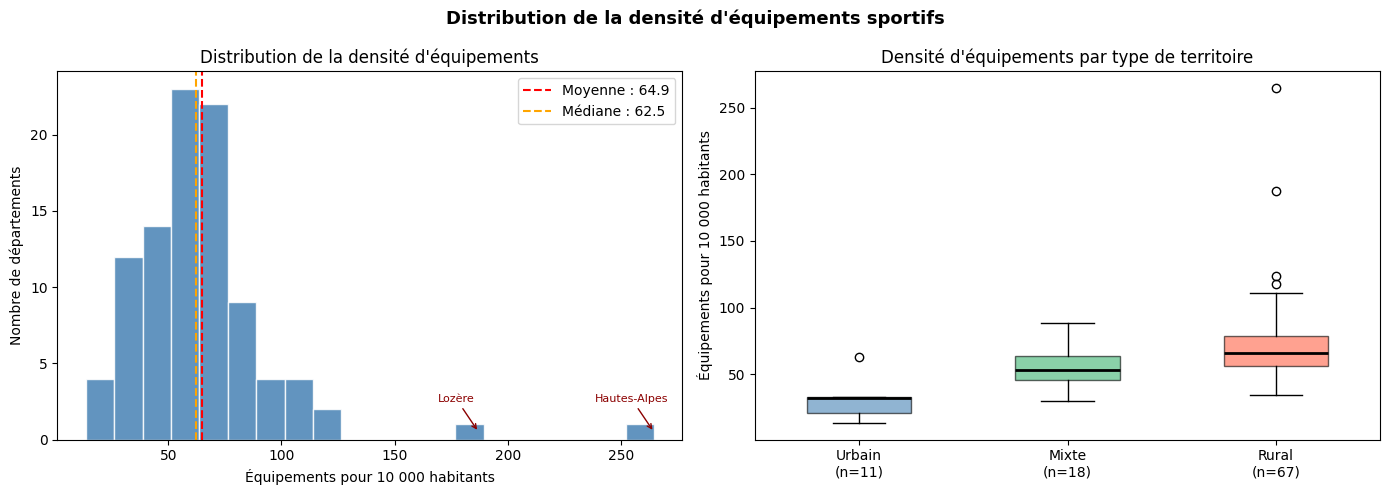

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogramme avec labels sur les valeurs extrêmes ---
data_equip = df["equip_10k"].dropna()

# Identifier les départements extrêmes (au-delà de 150)
seuil_extreme = 150
deps_extremes = df[df["equip_10k"] > seuil_extreme][["nom_dep", "equip_10k"]].sort_values("equip_10k")

n, bins, patches = axes[0].hist(data_equip, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(data_equip.mean(),   color="red",    ls="--", lw=1.5, label=f"Moyenne : {data_equip.mean():.1f}")
axes[0].axvline(data_equip.median(), color="orange", ls="--", lw=1.5, label=f"Médiane : {data_equip.median():.1f}")

# Ajouter le nom du département sur chaque valeur extrême
for _, row in deps_extremes.iterrows():
    axes[0].annotate(
        row["nom_dep"],
        xy=(row["equip_10k"], 0.5),
        xytext=(row["equip_10k"] - 10, 2.5),
        fontsize=8,
        color="darkred",
        arrowprops=dict(arrowstyle="->", color="darkred", lw=1),
        ha="center"
    )

axes[0].set_xlabel("Équipements pour 10 000 habitants")
axes[0].set_ylabel("Nombre de départements")
axes[0].set_title("Distribution de la densité d'équipements")
axes[0].legend()

# --- Boxplot par type de territoire ---
df["type_territoire"] = pd.cut(
    df["part_rural"],
    bins=[0, 33, 66, 100],
    labels=["Urbain", "Mixte", "Rural"],
    include_lowest=True
)
ordre = ["Urbain", "Mixte", "Rural"]
couleurs = ["steelblue", "mediumseagreen", "tomato"]
counts = df["type_territoire"].value_counts()

for i, (cat, col) in enumerate(zip(ordre, couleurs)):
    data_cat = df.loc[df["type_territoire"] == cat, "equip_10k"].dropna()
    axes[1].boxplot(data_cat, positions=[i], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=col, alpha=0.6),
                   medianprops=dict(color="black", lw=2))

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels([f"{cat}\n(n={counts.get(cat, 0)})" for cat in ordre])
axes[1].set_ylabel("Équipements pour 10 000 habitants")
axes[1].set_title("Densité d'équipements par type de territoire")

plt.suptitle("Distribution de la densité d'équipements sportifs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Pour cette étude, nous avons fixé qu'un département est caractérisé comme "urbain" si moins de 33% de ses communes sont rurales. Un département est jugé "rural" lorsque plus de 66% de ses villes sont rurales. Le statut du département est mixte lorsque le taux de villes rurales dans le territoire est compris entre 33% et 66%.

**Les départements principalement ruraux disposent de plus d'équipements sportifs pour 10 000 habitants** que les départements mixtes et urbains, qui ont une plus grande population.
La Lozère et les Hautes-Alpes sont deux départements disposant de beaucoup d'équipements pour 10 000 habitants. Il s'agit de deux territoires principalement ruraux comptant seulement quelques dizaines d'habitants. Il faudrait observer le nombre d'équipements sportifs par département selon la population de ce dernier.

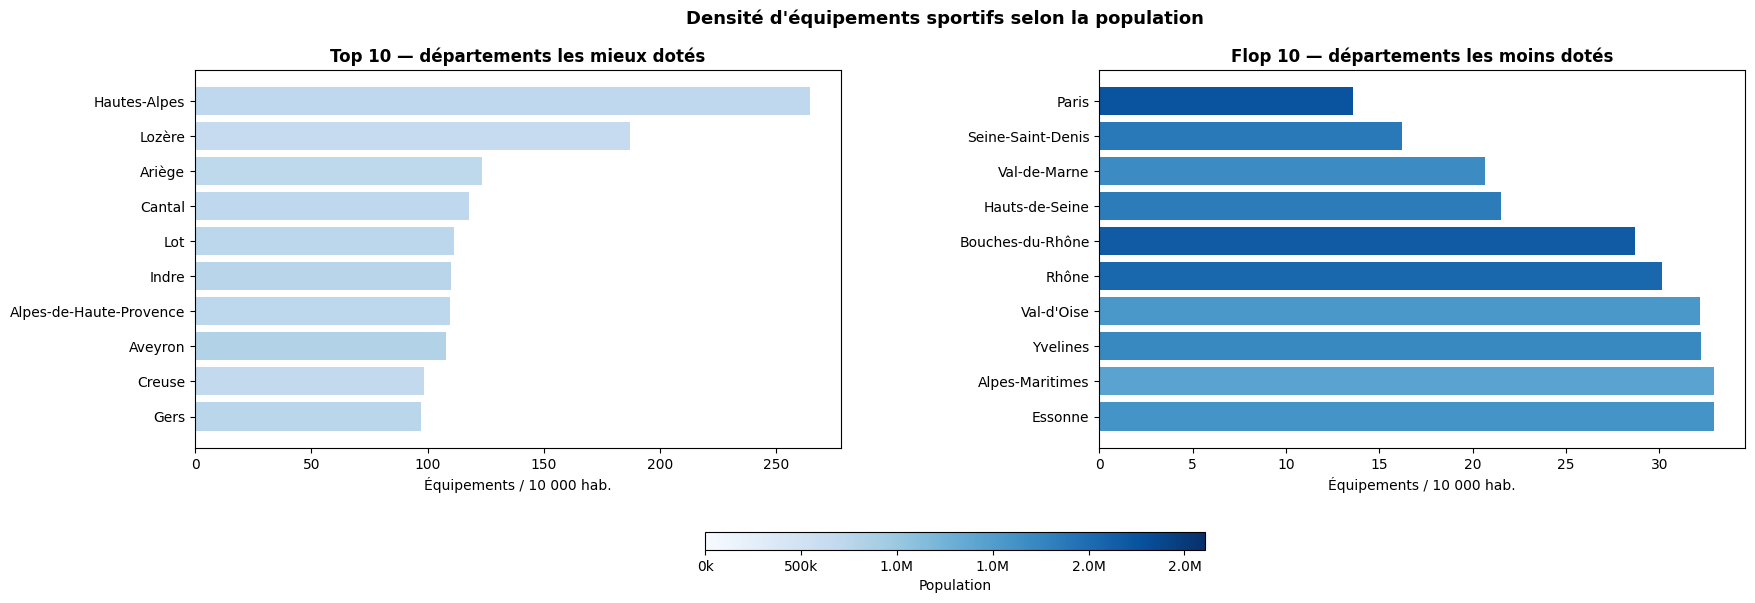

In [38]:
top10 = df.nlargest(10, "equip_10k")[["nom_dep", "equip_10k", "revenu_median", "taux_pauvrete", "part_rural", "population"]]
bot10 = df.nsmallest(10, "equip_10k")[["nom_dep", "equip_10k", "revenu_median", "taux_pauvrete", "part_rural", "population"]]

import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plt.subplots_adjust(bottom=0.25, wspace=0.4)

cmap = plt.cm.Blues
norm_display = plt.Normalize(vmin=0, vmax=df["population"].max())
norm_color   = plt.Normalize(vmin=-df["population"].max() * 0.3, vmax=df["population"].max())

# Top 10
colors_top = cmap(norm_color(top10["population"]))
axes[0].barh(top10["nom_dep"], top10["equip_10k"], color=colors_top)
axes[0].set_title("Top 10 — départements les mieux dotés", fontweight="bold")
axes[0].set_xlabel("Équipements / 10 000 hab.")
axes[0].invert_yaxis()

# Flop 10
colors_bot = cmap(norm_color(bot10["population"]))
axes[1].barh(bot10["nom_dep"], bot10["equip_10k"], color=colors_bot)
axes[1].set_title("Flop 10 — départements les moins dotés", fontweight="bold")
axes[1].set_xlabel("Équipements / 10 000 hab.")
axes[1].invert_yaxis()

# Colorbar courte centrée sous la figure [left, bottom, width, height]
cbar_ax = fig.add_axes([0.38, 0.08, 0.25, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_display)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label="Population")
cbar.formatter = mticker.FuncFormatter(
    lambda x, _: f"{int(x/1e6):.1f}M" if x >= 1e6 else f"{int(x/1e3)}k"
)
cbar.update_ticks()

plt.suptitle("Densité d'équipements sportifs selon la population",
             fontsize=13, fontweight="bold")
plt.show()

Les Hautes-Alpes et la Lozère sont suivies de huit autres territoires faiblement peuplés parmi les départements les mieux dotés en équipements pour 10 000 habitants.
À l'inverse, les départements les moins dotés apparaissent comme des zones fortement habitées (région parisienne et grandes villes françaises). Les départements urbains denses peuvent être sous-équipés par habitant, même s’ils ont beaucoup d’infrastructures au total. Ils disposent de plus d'équipements spécialisés, mais moins nombreux relativement à la population.
En zone rurale, les équipements sont plus simples mais nombreux, donc il y en a plus relativement au nombre d'habitants.

### 4.3 Liens avec les variables socio-économiques
Après ces analyses primaires, on va chercher à déterminer quelles variables contribuent le plus au nombre d'équipements pour 10 000 habitants avec une matrice de corrélation.

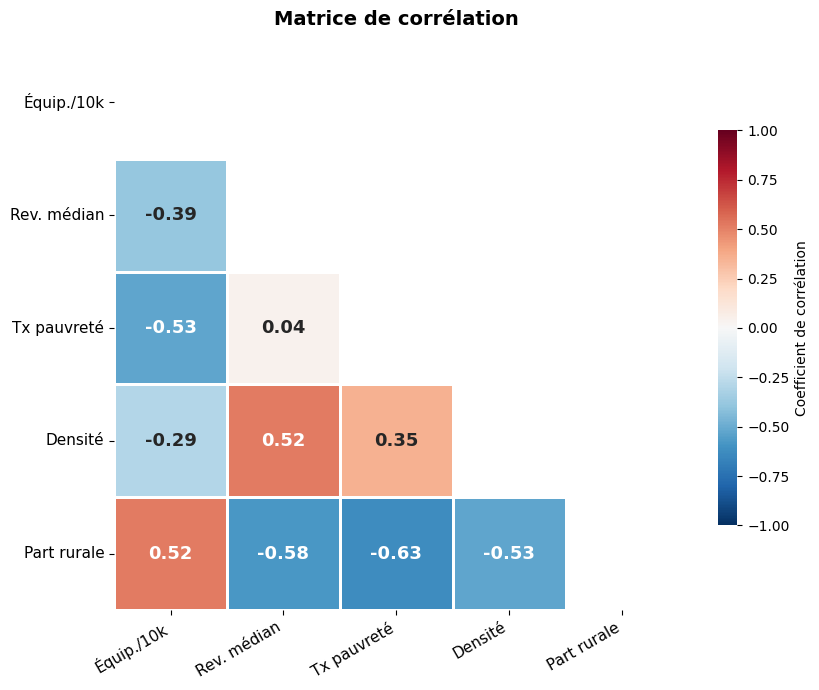

In [21]:
# Matrice de corrélation annotée
vars_corr = ["equip_10k", "revenu_median", "taux_pauvrete", "densite", "part_rural"]
labels_corr = ["Équip./10k", "Rev. médian", "Tx pauvreté", "Densité", "Part rurale"]

corr = df[vars_corr].corr()
corr.index   = labels_corr
corr.columns = labels_corr

# Masque triangle supérieur + diagonale
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    square=True,
    linewidths=1,
    linecolor="white",
    annot_kws={"size": 13, "weight": "bold"},
    cbar_kws={"shrink": 0.7, "label": "Coefficient de corrélation"},
    ax=ax
)

# Rotation des labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_title("Matrice de corrélation", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Deux variables semblent contribuer le plus au nombre d'équipements pour 10 000 habitants.

D'un côté, la part de villes rurales dans le département joue un rôle dans la possession d'un nombre important d'équipements pour 10 000 habitants (**plus il y a de villes rurales dans le département, plus l'indice relatif à la population est élevé**). Dans le même sens, les résultats mettent en évidence une corrélation négative entre la densité de population et la densité d’équipements sportifs : **à mesure que la densité démographique augmente, le nombre d’équipements pour 10 000 habitants tend à diminuer**.

De l'autre côté, le taux de pauvreté influe négativement sur le nombre d'équipements pour 10 000 habitants (**plus le taux de pauvreté est élevé, plus l'indice relatif à la population est faible**). La même observation est possible pour le revenu médian d'un département.

---
## 5 - Visualisation cartographique

In [ ]:
# Fusion GeoDataFrame + données analytiques
gdf = gdf_deps.merge(df, on="code_dep", how="left")
gdf = gdf.rename(columns={"nom_dep_x": "nom_dep"}).drop(columns=["nom_dep_y"], errors="ignore")
print(f"GeoDataFrame : {len(gdf)} départements")

In [ ]:
# Carte choroplèthe interactive — densité d'équipements
m = folium.Map(location=[46.5, 2.5], zoom_start=6, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=gdf.__geo_interface__,
    data=gdf,
    columns=["code_dep", "equip_10k"],
    key_on="feature.properties.code_dep",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name="Équipements / 10 000 habitants",
    nan_fill_color="lightgray",
).add_to(m)

folium.GeoJson(
    gdf.__geo_interface__,
    tooltip=folium.GeoJsonTooltip(
        fields=["nom_dep", "equip_10k", "revenu_median", "taux_pauvrete"],
        aliases=["Département", "Équip./10k hab.", "Revenu médian (€)", "Taux pauvreté (%)"],
    ),
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
).add_to(m)

m.save("carte_choroplethe.html")
m

---
## 6 - Modélisation

**Variable cible** : `equip_10k` (équipements pour 10 000 habitants)  
**Variables explicatives** : `revenu_median`, `taux_pauvrete`, `densite`, `part_rural`  
On compare une régression linéaire (interprétable) et un Random Forest (plus flexible).

## 6.1 - Objectif de la modélisation

On cherche à expliquer la densité d’équipements sportifs (`equip_10k`) en fonction de variables socio-économiques et territoriales.

Variables explicatives :
- revenu médian
- taux de pauvreté
- densité de population
- part rurale

Deux modèles sont comparés :
- Régression linéaire (interprétable)
- Random Forest (non linéaire, plus flexible)

In [22]:
features = ['revenu_median', 'taux_pauvrete', 'densite', 'part_rural']
target   = 'equip_10k'

df_model = df[features + [target, 'nom_dep']].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model[target]

print(f"{len(df_model)} départements utilisés")
df_model.head()

96 départements utilisés


,revenu_median,taux_pauvrete,densite,part_rural,equip_10k,nom_dep
0,25257.848413,7.439797,113.672273,56.887755,62.471764,Ain
1,19823.451306,11.030959,71.452594,84.335840,68.734239,Aisne
2,20881.861078,9.408732,45.495159,74.447950,72.908101,Allier
3,20733.672507,9.633372,23.646905,100.000000,109.458389,Alpes-de-Haute-Provence
4,21190.120550,7.705437,24.709218,100.000000,264.570961,Hautes-Alpes


## 6.2 - Séparation apprentissage / test

On sépare les données en :
- 80% apprentissage
- 20% test

Cela permet d’évaluer la capacité de généralisation des modèles.

In [23]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")

Train : 76
Test  : 20


## 6.3 - Régression linéaire (OLS)

La régression linéaire permet d’obtenir un modèle interprétable reliant directement les variables explicatives à la variable cible.

On évalue la performance via le coefficient de détermination (R²).

In [24]:
# Pipeline OLS
pipe_ols = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('ols', LinearRegression())
])

pipe_ols.fit(X_train, y_train)
y_pred_ols = pipe_ols.predict(X_test)
print("R² OLS          :", round(r2_score(y_test, y_pred_ols), 3))


R² OLS          : 0.693


Le modèle explique environ **69,3% de la variabilité** de `equip_10k`.

C’est un résultat plutôt correct : les variables socio-économiques captent une bonne partie des différences, mais il reste encore une part importante non expliquée.

## 6.4 - Random Forest

Le Random Forest permet de capturer des relations non linéaires et des interactions entre variables.

Il est comparé à la régression linéaire.

In [25]:
# Pipeline Random Forest
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('randomforest', RandomForestRegressor(random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf  = pipe_rf.predict(X_test)
print("R² Random Forest:", round(r2_score(y_test, y_pred_rf), 3))

R² Random Forest: 0.875


In [26]:
print("Moyenne equip_10k :", round(y.mean(), 2))
print("Variance equip_10k :", round(y.var(), 2))

Moyenne equip_10k : 64.89
Variance equip_10k : 1093.58


Le Random Forest fait nettement mieux que la régression linéaire avec un R² de 0,872.

Cette amélioration importante suggère que les relations entre variables sont principalement non linéaires, avec des interactions que les modèles linéaires ne parviennent pas à capturer.

La variance élevée de equip_10k (1093,35) montre qu’il existe de fortes disparités entre départements, que le modèle explique désormais en grande partie, même s’il reste une part de variabilité non expliquée.

## 6.5 - Analyse des erreurs (résidus)

Les résidus mesurent l’erreur entre valeurs observées et prédites.

On analyse :
- moyenne (biais global)
- variance (dispersion)
- distribution des erreurs

In [27]:
residus = y_test - y_pred_rf

print("Moyenne des résidus :", round(residus.mean(), 3))
print("Variance des résidus :", round(residus.var(), 3))

Moyenne des résidus : 0.991
Variance des résidus : 62.273


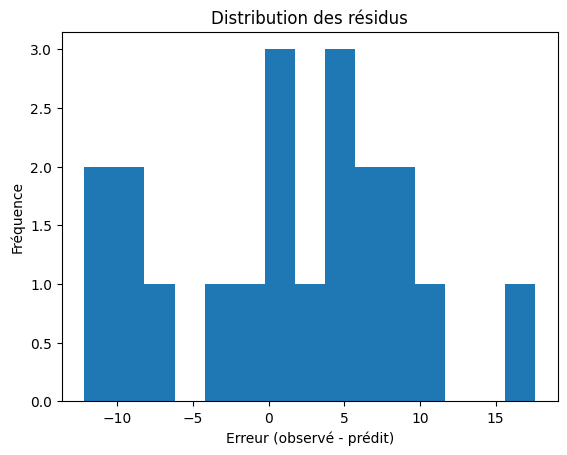

In [28]:
plt.hist(residus, bins=15)
plt.title("Distribution des résidus")
plt.xlabel("Erreur (observé - prédit)")
plt.ylabel("Fréquence")
plt.show()

Les erreurs sont globalement **faiblement biaisées** (moyenne ≈ 1,02), ce qui indique qu’il n’y a pas de biais systématique important du modèle.

En revanche, la **variance relativement élevée des résidus (63,74)** montre que certaines prédictions s’écartent fortement des valeurs réelles.

On observe donc un modèle globalement performant, mais avec quelques départements pour lesquels les estimations restent nettement imprécises.


In [29]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))

MAE : 6.43
RMSE : 7.76


Le modèle présente une erreur absolue moyenne (MAE) de 6,51, ce qui signifie qu’en moyenne, la prédiction s’écarte de 6,5 équipements pour 10 000 habitants.

Le RMSE, égal à 7,85, est plus élevé, ce qui indique la présence de quelques erreurs plus importantes.

Cela confirme que le modèle est globalement précis, mais avec des écarts notables pour certains départements.

## 6.6 - Intervalle de confiance des erreurs

On calcule un intervalle de confiance à 95% sur l’erreur moyenne.

S’il contient 0 → pas de biais global du modèle.

In [30]:
mean_res = residus.mean()
std_res  = residus.std()
n        = len(residus)

ic_bas  = mean_res - 1.96 * std_res / np.sqrt(n)
ic_haut = mean_res + 1.96 * std_res / np.sqrt(n)

print(f"IC 95% de l'erreur moyenne : [{ic_bas:.3f} ; {ic_haut:.3f}]")

IC 95% de l'erreur moyenne : [-2.467 ; 4.450]


L’intervalle de confiance à 95% de l’erreur moyenne est **[-2,483 ; 4,515]**.

Comme il contient 0, cela indique qu’il n’y a pas de biais global significatif du modèle.

En revanche, la largeur de cet intervalle montre une **variabilité non négligeable des erreurs**, selon les départements, ce qui confirme que les performances du modèle ne sont pas totalement homogènes sur l’ensemble des observations.


## 6.7 - Validation croisée

La validation croisée permet d’évaluer la stabilité du modèle sur plusieurs découpages.

On observe :
- moyenne du R²
- variabilité du modèle

In [31]:
scores = cross_val_score(pipe_rf, X, y, cv=5, scoring="r2")

print("R² moyen (CV) :", round(scores.mean(), 3))
print("Écart-type    :", round(scores.std(), 3))

R² moyen (CV) : 0.263
Écart-type    : 0.473


Le **R²** moyen en validation croisée **(0,259)** est nettement inférieur au **R²** sur le test set **(0,872)**. Cela s'explique principalement par la taille très réduite de l'échantillon (96 départements) : avec une CV à 5 folds, chaque fold de test ne contient qu'une vingtaine d'observations, ce qui rend l'estimation du R² très sensible à la composition de chaque fold. 

In [32]:
print("R² train :", round(pipe_rf.score(X_train, y_train), 3))
print("R² test  :", round(pipe_rf.score(X_test, y_test), 3))

R² train : 0.897
R² test  : 0.875


Les performances sont proches entre l’entraînement (**R² = 0,897**) et le test (**R² = 0,872**), ce qui indique une **absence de surapprentissage marqué**.

Cela suggère que la faible performance observée en validation croisée ne s’explique pas par un surapprentissage, mais plutôt par une **sensibilité du modèle au découpage des données**.

Afin d’améliorer la robustesse du modèle, une optimisation des hyperparamètres va être réalisée.

In [33]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", round(grid.best_score_, 3))

Meilleurs paramètres : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Meilleur score CV : 0.366


Les meilleurs paramètres obtenus sont :
- `max_depth = 5`
- `min_samples_split = 5`
- `n_estimators = 50`

Le score moyen associé est de **0,357**, ce qui reste modéré.

Cette optimisation n’apporte qu’une **amélioration limitée des performances**, ce qui suggère que le modèle était déjà proche de son optimum.



Ainsi, malgré de bonnes performances sur le jeu de test, le modèle présente une **stabilité limitée** selon les échantillons.

Cela met en évidence une **forte dépendance à la structure des données**, probablement liée à l’hétérogénéité des départements, et limite la capacité de généralisation du modèle.

## 6.8 - Importance des variables

On identifie les variables les plus influentes dans le Random Forest.

Cela permet de comprendre les facteurs principaux des inégalités territoriales.

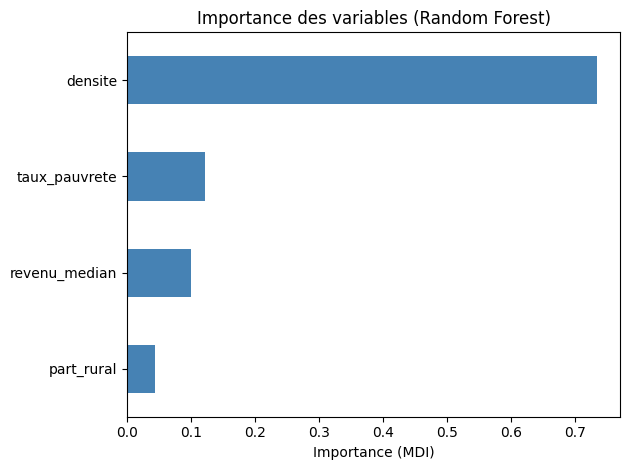

In [34]:
importances = pd.Series(
    pipe_rf['randomforest'].feature_importances_,
    index=features
).sort_values()

importances.plot(kind='barh', color='steelblue')
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance (MDI)")
plt.tight_layout()
plt.show()

La variable la plus influente est clairement la **densité de population (0,736)**.

Elle est suivie par le **taux de pauvreté** et le **revenu médian**, tandis que la **part rurale** joue un rôle plus limité.

Globalement, la structure territoriale, et en particulier la **densité de population**, apparaît comme le facteur principal explicatif des différences d’équipements entre les départements.


## 6.10 - Qualité des prédictions

On compare les valeurs réelles et prédites.

Plus les points sont proches de la diagonale, plus le modèle est précis.

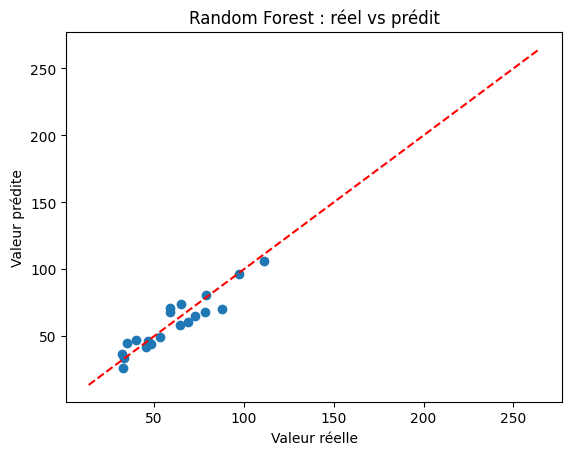

In [35]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite")
plt.title("Random Forest : réel vs prédit")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.show()

Les points sont globalement bien répartis selon les différentes classes de prédiction, ce qui indique que le modèle parvient à capturer la structure générale des données.

Cependant, on observe encore quelques confusions entre certaines valeurs proches, ce qui suggère que le modèle a parfois du mal à discriminer précisément les niveaux intermédiaires de equip_10k.

Les cas extrêmes semblent globalement mieux isolés, mais une certaine incertitude persiste sur les zones de transition entre classes.

## 6.11 - Synthèse de la modélisation

Les modèles testés permettent d’expliquer une part importante des disparités territoriales d’équipements sportifs, avec des performances nettement supérieures pour le Random Forest (R² = 0,872) par rapport à la régression linéaire (R² ≈ 0,69).

Les variables socio-économiques et territoriales jouent donc un rôle significatif dans l’explication de `equip_10k`, mais elles ne suffisent pas à capturer l’ensemble des disparités observées entre départements.

L’analyse des erreurs montre un modèle globalement précis (MAE = 6,51 ; RMSE = 7,85), sans biais significatif, mais avec des écarts importants sur certains territoires.

Cependant, la validation croisée met en évidence une forte instabilité des performances (R² moyen faible et variance élevée), suggérant que le modèle est sensible à la composition des données et que la généralisation reste limitée.

Enfin, l’analyse des variables importantes montre que la densité de population est le principal facteur explicatif, devant les variables socio-économiques comme le revenu médian ou le taux de pauvreté.

Ainsi, les inégalités d’accès aux équipements sportifs apparaissent fortement liées à la structure territoriale, mais également influencées par des facteurs non observés dans les données disponibles.